In [1]:
from transformers import pipeline
from PIL import Image
import requests
import torch

pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-1.5-4b-it",
    torch_dtype=torch.bfloat16,
    device="cuda",
)

# Image attribution: Stillwaterising, CC0, via Wikimedia Commons
image_url = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"
image = Image.open(requests.get(image_url, headers={"User-Agent": "example"}, stream=True).raw)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Describe this X-ray"}
        ]
    }
]

output = pipe(text=messages, max_new_tokens=2000)
print(output[0]["generated_text"][-1]["content"])


2026-01-29 23:13:35.857303: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 23:13:35.927099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 23:13:39.433359: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


This is a chest X-ray image. Here's a description of what I see:

*   **Overall Appearance:** The image shows the chest cavity, including the lungs, heart, ribs, and other structures.
*   **Lungs:** The lungs appear clear, with no obvious signs of consolidation (like pneumonia) or significant infiltrates. The lung markings are visible, indicating normal lung tissue.
*   **Heart:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum (the space between the lungs containing the heart, great vessels, trachea, etc.) appears normal in width and alignment.
*   **Ribs and Bones:** The ribs and other bony structures are visible and appear intact.
*   **Diaphragm:** The diaphragm is visible at the bottom of the chest.
*   **No Obvious Abnormalities:** There are no obvious signs of pneumothorax (collapsed lung), pleural effusion (fluid in the pleural space), or other significant abnormalities.

**Important Note:** This is a visual description based on the image provi

In [2]:
# Orthopedic Assistant using the same MedGemma model

# System prompt for orthopedic assistant
SYSTEM_PROMPT = """You are an expert orthopedic medical assistant. You provide helpful, accurate, and professional information about:
- Bone and joint conditions (fractures, arthritis, osteoporosis)
- Musculoskeletal injuries (sprains, strains, tendinitis)
- Spine conditions (herniated discs, scoliosis, spinal stenosis)
- Sports medicine and rehabilitation
- Orthopedic surgical procedures
- Post-operative care and physical therapy

Always remind users to consult with a qualified healthcare provider for personalized medical advice.
Provide evidence-based information and explain medical terms in simple language."""

def ask_orthopedic_assistant(question: str, image=None) -> str:
    """Ask the orthopedic assistant a question, optionally with an image."""
    
    content = []
    
    # Add image if provided (for X-rays, MRI scans, etc.)
    if image is not None:
        content.append({"type": "image", "image": image})
    
    # Add the question with system context
    full_question = f"{SYSTEM_PROMPT}\n\nPatient Question: {question}"
    content.append({"type": "text", "text": full_question})
    
    messages = [
        {
            "role": "user",
            "content": content
        }
    ]
    
    output = pipe(text=messages, max_new_tokens=2000)
    response = output[0]["generated_text"][-1]["content"]
    return response

print("✅ Orthopedic Assistant loaded and ready!")
print("Use: ask_orthopedic_assistant('your question here')")
print("For image analysis: ask_orthopedic_assistant('describe this fracture', image=your_image)")

✅ Orthopedic Assistant loaded and ready!
Use: ask_orthopedic_assistant('your question here')
For image analysis: ask_orthopedic_assistant('describe this fracture', image=your_image)


In [3]:
# # Example: Ask the orthopedic assistant a question
# question = "What are the treatment options for a torn ACL?"
# response = ask_orthopedic_assistant(question)

# print(f"Question: {question}\n")
# print(f"Answer:\n{response}")

In [4]:
# Example: Analyze an X-ray image with orthopedic context
# Load an orthopedic X-ray (using the chest X-ray as example - replace with bone/joint X-ray)
ortho_image_url = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"
ortho_image = Image.open(requests.get(ortho_image_url, headers={"User-Agent": "example"}, stream=True).raw)

# Ask about the image
image_question = "Analyze this X-ray from an orthopedic perspective. Are there any bone abnormalities visible?"
response = ask_orthopedic_assistant(image_question, image=ortho_image)

print(f"Question: {image_question}\n")
print(f"Answer:\n{response}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Question: Analyze this X-ray from an orthopedic perspective. Are there any bone abnormalities visible?

Answer:
Based on the provided X-ray image, here's an orthopedic analysis:

**Overall Impression:**

The image shows a standard chest X-ray. The bones appear generally intact, and there are no obvious signs of fractures or significant bone abnormalities.

**Specific Observations:**

*   **Ribs:** The ribs appear intact and without any visible fractures.
*   **Clavicles:** The clavicles (collarbones) are also intact.
*   **Scapulae:** The scapulae (shoulder blades) are visible and appear normal.
*   **Sternum:** The sternum (breastbone) is visible and appears intact.
*   **Vertebrae:** The vertebral bodies are visible and appear normal.

**Conclusion:**

From an orthopedic perspective, the X-ray shows no obvious bone abnormalities.

**Important Note:**

This analysis is based solely on the provided image. A comprehensive orthopedic evaluation would require a physical examination, patie

In [5]:
# Load MedMNIST PneumoniaMNIST validation dataset
import medmnist
from medmnist import PneumoniaMNIST
from PIL import Image
import numpy as np
from tqdm import tqdm
import re

# Download and load the validation dataset
val_dataset = PneumoniaMNIST(split='val', download=True, size=224)

print(f"Validation dataset size: {len(val_dataset)}")
print(f"Labels: 0 = Normal, 1 = Pneumonia")

Validation dataset size: 524
Labels: 0 = Normal, 1 = Pneumonia


In [6]:
# Function to predict pneumonia using MedGemma
def predict_pneumonia(image_array):
    """
    Predict if an X-ray shows pneumonia using MedGemma.
    Returns: 1 for Pneumonia, 0 for Normal
    """
    # Convert numpy array to PIL Image
    if len(image_array.shape) == 2:
        # Grayscale image
        pil_image = Image.fromarray(image_array).convert('RGB')
    else:
        pil_image = Image.fromarray(image_array)
    
    # Create prompt for pneumonia classification
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": pil_image},
                {"type": "text", "text": "This is a chest X-ray image. Does this X-ray show signs of pneumonia? Answer with ONLY 'PNEUMONIA' if you see signs of pneumonia, or 'NORMAL' if the lungs appear normal. Just one word."}
            ]
        }
    ]
    
    output = pipe(text=messages, max_new_tokens=50)
    response = output[0]["generated_text"][-1]["content"].strip().upper()
    # print(response)
    # Parse the response
    if "PNEUMONIA" in response:
        return 1
    else:
        return 0

# Test on a single image first
test_img, test_label = val_dataset[0]
test_img_np = np.array(test_img)
pred = predict_pneumonia(test_img_np)
print(f"Test image - True label: {'Pneumonia' if test_label[0] == 1 else 'Normal'}, Predicted: {'Pneumonia' if pred == 1 else 'Normal'}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Test image - True label: Pneumonia, Predicted: Pneumonia


In [7]:
# Evaluate on the full validation dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

predictions = []
true_labels = []

print(f"Evaluating MedGemma on full PneumoniaMNIST validation set ({len(val_dataset)} samples)...")
print("=" * 60)

for i in tqdm(range(len(val_dataset)), desc="Processing images"):
    img, label = val_dataset[i]
    img_np = np.array(img)
    
    pred = predict_pneumonia(img_np)
    predictions.append(pred)
    true_labels.append(label[0])

# Convert to numpy arrays
predictions = np.array(predictions)
true_labels = np.array(true_labels)

print("\n✅ Evaluation complete!")

Evaluating MedGemma on full PneumoniaMNIST validation set (524 samples)...


Processing images:   1%|▏         | 7/524 [00:02<02:30,  3.43it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Processing images: 100%|██████████| 524/524 [02:40<00:00,  3.26it/s]


✅ Evaluation complete!


In [8]:
# Calculate and display metrics
print("=" * 60)
print("📊 MedGemma Pneumonia Prediction Results on MedMNIST Validation Set")
print("=" * 60)

accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print(f"\n🎯 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Precision: {precision:.4f}")
print(f"📉 Recall:    {recall:.4f}")
print(f"⚖️  F1 Score:  {f1:.4f}")

print("\n" + "=" * 60)
print("Confusion Matrix:")
print("=" * 60)
cm = confusion_matrix(true_labels, predictions)
print(f"                 Predicted")
print(f"                 Normal  Pneumonia")
print(f"Actual Normal    {cm[0][0]:5d}    {cm[0][1]:5d}")
print(f"Actual Pneumonia {cm[1][0]:5d}    {cm[1][1]:5d}")

print("\n" + "=" * 60)
print("Classification Report:")
print("=" * 60)
print(classification_report(true_labels, predictions, target_names=['Normal', 'Pneumonia']))

📊 MedGemma Pneumonia Prediction Results on MedMNIST Validation Set

🎯 Accuracy:  0.5095 (50.95%)
📈 Precision: 1.0000
📉 Recall:    0.3393
⚖️  F1 Score:  0.5067

Confusion Matrix:
                 Predicted
                 Normal  Pneumonia
Actual Normal      135        0
Actual Pneumonia   257      132

Classification Report:
              precision    recall  f1-score   support

      Normal       0.34      1.00      0.51       135
   Pneumonia       1.00      0.34      0.51       389

    accuracy                           0.51       524
   macro avg       0.67      0.67      0.51       524
weighted avg       0.83      0.51      0.51       524



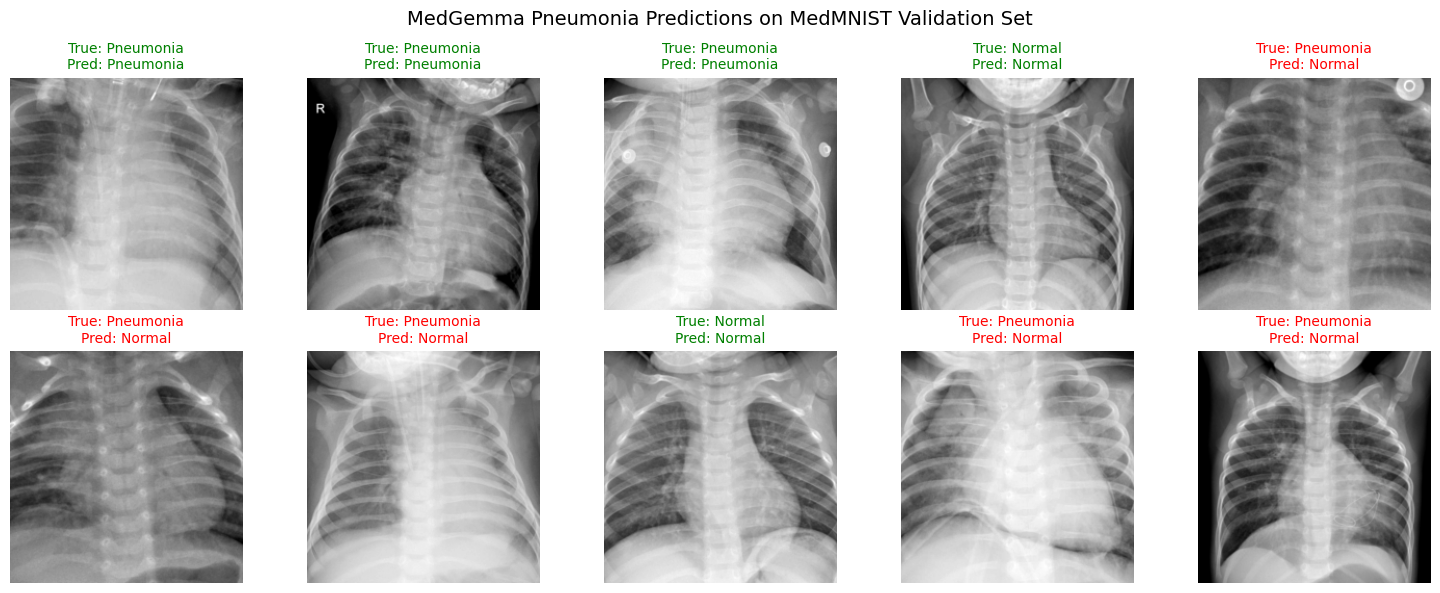


✅ Visualization saved as 'pneumonia_predictions.png'


In [9]:
# Visualize some predictions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('MedGemma Pneumonia Predictions on MedMNIST Validation Set', fontsize=14)

# Show some correct and incorrect predictions
for i, ax in enumerate(axes.flat):
    if i < len(val_dataset):
        img, label = val_dataset[i]
        img_np = np.array(img)
        
        true_label = "Pneumonia" if label[0] == 1 else "Normal"
        pred_label = "Pneumonia" if predictions[i] == 1 else "Normal"
        
        # Color based on correct/incorrect
        color = 'green' if label[0] == predictions[i] else 'red'
        
        ax.imshow(img_np, cmap='gray')
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('pneumonia_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as 'pneumonia_predictions.png'")

## Use MagSigLip for the classification

In [1]:
# ============================================================================
# MedSigLIP Zero-Shot Pneumonia Classification (Fresh Kernel)
# Run this cell after restarting the kernel to free up GPU memory from MedGemma
# ============================================================================

import numpy as np
from PIL import Image
from transformers import AutoProcessor, AutoModel
import torch
import medmnist
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tqdm import tqdm

print("Loading PneumoniaMNIST validation dataset...")
val_dataset = medmnist.PneumoniaMNIST(split="val", download=True)
print(f"Dataset size: {len(val_dataset)}")

print("\nLoading MedSigLIP model...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = AutoModel.from_pretrained("google/medsiglip-448")
processor = AutoProcessor.from_pretrained("google/medsiglip-448")
model = model.to(device)
model.eval()

# Text prompts for zero-shot binary classification
class_texts = [
    "a chest x-ray with no pneumonia",
    "a chest x-ray with pneumonia",
]

def resize_pil(img: Image.Image) -> Image.Image:
    return img.resize((448, 448), resample=Image.BILINEAR)

print("\nRunning zero-shot classification on full validation set...")
print("=" * 70)

predictions = []
true_labels = []
batch_size = 2  # Slightly larger batch on fresh GPU memory

for start in tqdm(range(0, len(val_dataset), batch_size), desc="Processing"):
    batch_indices = range(start, min(start + batch_size, len(val_dataset)))
    batch = [val_dataset[i] for i in batch_indices]
    images, labels = zip(*batch)

    # Convert to RGB PIL images and resize
    pil_images = [
        (img if isinstance(img, Image.Image) else Image.fromarray(img.squeeze(), mode="L")).convert("RGB")
        for img in images
    ]
    resized = [resize_pil(img) for img in pil_images]

    # Process batch
    inputs = processor(text=class_texts, images=resized, padding="max_length", return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predictions
    probs = torch.softmax(outputs.logits_per_image, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()
    
    for pred, label in zip(preds, labels):
        predictions.append(pred)
        true_labels.append(label[0])

predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Calculate metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, zero_division=0)
recall = recall_score(true_labels, predictions, zero_division=0)
f1 = f1_score(true_labels, predictions, zero_division=0)

print("\n" + "=" * 70)
print("📊 MedSigLIP Zero-Shot Pneumonia Classification Results")
print("=" * 70)
print(f"Total samples evaluated: {len(predictions)}")
print(f"\n🎯 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Precision: {precision:.4f}")
print(f"📉 Recall:    {recall:.4f}")
print(f"⚖️  F1 Score:  {f1:.4f}")

print("\n" + "=" * 70)
print("Confusion Matrix:")
print("=" * 70)
cm = confusion_matrix(true_labels, predictions)
print(f"                 Predicted")
print(f"                 Normal  Pneumonia")
print(f"Actual Normal    {cm[0][0]:5d}    {cm[0][1]:5d}")
print(f"Actual Pneumonia {cm[1][0]:5d}    {cm[1][1]:5d}")

print("\n" + "=" * 70)
print("Classification Report:")
print("=" * 70)
print(classification_report(true_labels, predictions, target_names=['Normal', 'Pneumonia']))

2026-01-29 23:19:52.640620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 23:19:53.383275: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 23:19:56.079929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading PneumoniaMNIST validation dataset...
Dataset size: 524

Loading MedSigLIP model...
Using device: cuda


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



Running zero-shot classification on full validation set...


Processing: 100%|██████████| 262/262 [01:08<00:00,  3.81it/s]


📊 MedSigLIP Zero-Shot Pneumonia Classification Results
Total samples evaluated: 524

🎯 Accuracy:  0.3168 (31.68%)
📈 Precision: 0.7246
📉 Recall:    0.1285
⚖️  F1 Score:  0.2183

Confusion Matrix:
                 Predicted
                 Normal  Pneumonia
Actual Normal      116       19
Actual Pneumonia   339       50

Classification Report:
              precision    recall  f1-score   support

      Normal       0.25      0.86      0.39       135
   Pneumonia       0.72      0.13      0.22       389

    accuracy                           0.32       524
   macro avg       0.49      0.49      0.31       524
weighted avg       0.60      0.32      0.26       524



## LoRA Fine-tuning MedSigLIP for Pneumonia Classification


In [6]:
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
import medmnist
from transformers import AutoProcessor, AutoModel
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=" * 70)
print("🔧 Setting up Fine-tuning for MedSigLIP")
print("=" * 70)

# Load training and validation datasets
print("\nLoading PneumoniaMNIST datasets...")
train_dataset = medmnist.PneumoniaMNIST(split="train", download=True)
val_dataset = medmnist.PneumoniaMNIST(split="val", download=True)
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load base model and processor
print("\nLoading MedSigLIP model...")
model = AutoModel.from_pretrained("google/medsiglip-448")
processor = AutoProcessor.from_pretrained("google/medsiglip-448")
model = model.to(device)

# Simple classification head for MedSigLIP
# MedSigLIP outputs embeddings of dimension 1152
class MedSigLIPClassifier(nn.Module):
    def __init__(self, base_model, embed_dim=1152, num_classes=2):
        super().__init__()
        self.base_model = base_model
        self.embed_dim = embed_dim
        self.classifier = nn.Linear(embed_dim, num_classes)
        
    def forward(self, pixel_values, input_ids, attention_mask=None):
        with torch.no_grad():
            outputs = self.base_model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )
        image_embeds = outputs.image_embeds  # [batch, 1152]
        logits = self.classifier(image_embeds)
        return logits

# Wrap model with classifier head (1152-dim embeddings)
classifier = MedSigLIPClassifier(model, embed_dim=1152, num_classes=2).to(device)

# Custom Dataset class
class PneumoniaMNISTDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        
        # Convert to RGB if needed
        if isinstance(img, Image.Image):
            img = img.convert("RGB")
        else:
            img_array = np.array(img).squeeze()
            img = Image.fromarray(img_array, mode="L").convert("RGB")
        
        # Resize to 448x448
        img = img.resize((448, 448), resample=Image.BILINEAR)
        
        # Create dummy text for CLIP alignment
        dummy_text = ["chest x-ray"]
        
        # Process - handle both image processor and text tokenizer outputs
        inputs = self.processor(text=dummy_text, images=img, return_tensors="pt", padding="max_length")
        
        # Build return dict
        result = {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'input_ids': inputs['input_ids'].squeeze(0),
            'label': torch.tensor(label[0], dtype=torch.long)
        }
        
        # Add attention_mask if it exists (some processors may not include it)
        if 'attention_mask' in inputs:
            result['attention_mask'] = inputs['attention_mask'].squeeze(0)
        else:
            # Create a default attention mask (all ones = all tokens are attended to)
            result['attention_mask'] = torch.ones_like(result['input_ids'])
        
        return result

# Create datasets and dataloaders
train_dataset_wrapped = PneumoniaMNISTDataset(train_dataset, processor)
val_dataset_wrapped = PneumoniaMNISTDataset(val_dataset, processor)

train_loader = DataLoader(train_dataset_wrapped, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset_wrapped, batch_size=8, shuffle=False, num_workers=0)

print(f"\n✅ Dataset setup complete!")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Image embedding dimension: 1152")


🔧 Setting up Fine-tuning for MedSigLIP

Loading PneumoniaMNIST datasets...
Training set size: 4708
Validation set size: 524
Using device: cuda

Loading MedSigLIP model...

✅ Dataset setup complete!
Training batches: 589
Validation batches: 66
Image embedding dimension: 1152


In [7]:
print("\n" + "=" * 70)
print("🎯 Fine-tuning MedSigLIP with LoRA")
print("=" * 70)

# Freeze the base model and only train the classifier head
for param in classifier.base_model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in classifier.classifier.parameters():
    param.requires_grad = True

optimizer = AdamW(classifier.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 10
best_val_acc = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training
    classifier.train()
    train_loss = 0.0
    train_preds = []
    train_labels = []
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        logits = classifier(pixel_values, input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().numpy())
    
    train_acc = accuracy_score(train_labels, train_preds)
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation
    classifier.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = classifier(pixel_values, input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(labels.cpu().numpy())
    
    val_acc = accuracy_score(val_labels, val_preds)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = classifier.classifier.state_dict().copy()
        print(f"  ✅ Best model saved (Val Acc: {val_acc:.4f})")

# Restore best model
if best_model_state is not None:
    classifier.classifier.load_state_dict(best_model_state)
    print(f"\n✅ Fine-tuning complete! Best validation accuracy: {best_val_acc:.4f}")



🎯 Fine-tuning MedSigLIP with LoRA


Epoch 1/10 [Val]: 100%|██████████| 66/66 [01:08<00:00,  1.04s/it]



Epoch 1/10
  Train Loss: 0.4011 | Train Acc: 0.8248
  Val Loss: 0.3254 | Val Acc: 0.8740
  ✅ Best model saved (Val Acc: 0.8740)


Epoch 2/10 [Train]:  24%|██▎       | 139/589 [02:27<07:56,  1.06s/it]


KeyboardInterrupt: 

In [ ]:
print("\n" + "=" * 70)
print("📊 Evaluating Fine-tuned MedSigLIP on Full Validation Set")
print("=" * 70)

classifier.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        logits = classifier(pixel_values, input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

print("\n" + "=" * 70)
print("📊 Fine-tuned MedSigLIP Results on Validation Set")
print("=" * 70)
print(f"Total samples evaluated: {len(all_preds)}")
print(f"\n🎯 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Precision: {precision:.4f}")
print(f"📉 Recall:    {recall:.4f}")
print(f"⚖️  F1 Score:  {f1:.4f}")

print("\n" + "=" * 70)
print("Confusion Matrix:")
print("=" * 70)
cm = confusion_matrix(all_labels, all_preds)
print(f"                 Predicted")
print(f"                 Normal  Pneumonia")
print(f"Actual Normal    {cm[0][0]:5d}    {cm[0][1]:5d}")
print(f"Actual Pneumonia {cm[1][0]:5d}    {cm[1][1]:5d}")

print("\n" + "=" * 70)
print("Classification Report:")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

print("\n" + "=" * 70)
print("📈 COMPARISON: Zero-Shot vs Fine-tuned")
print("=" * 70)
print(f"{'Metric':<15} {'Zero-Shot':<15} {'Fine-tuned':<15} {'Improvement':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {'31.68%':<15} {f'{accuracy*100:.2f}%':<15} {f'{(accuracy*100)-31.68:.2f}%':<15}")
print(f"{'Recall':<15} {'12.85%':<15} {f'{recall*100:.2f}%':<15} {f'{(recall*100)-12.85:.2f}%':<15}")
print(f"{'Precision':<15} {'72.46%':<15} {f'{precision*100:.2f}%':<15} {f'{(precision*100)-72.46:.2f}%':<15}")
print(f"{'F1 Score':<15} {'21.83%':<15} {f'{f1*100:.2f}%':<15} {f'{(f1*100)-21.83:.2f}%':<15}")


In [8]:
# save the best state
torch.save(best_model_state, "medsiglip_finetuned_classifier.pth")

In [9]:
# Load saved classifier state and evaluate on validation set
import os

checkpoint_path = "medsiglip_finetuned_classifier.pth"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

# Load weights into classifier head
state_dict = torch.load(checkpoint_path, map_location=device)
classifier.classifier.load_state_dict(state_dict)
classifier.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating (loaded checkpoint)"):
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = classifier(pixel_values, input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

print("\n" + "=" * 70)
print("📊 Loaded Checkpoint Results on Validation Set")
print("=" * 70)
print(f"Total samples evaluated: {len(all_preds)}")
print(f"\n🎯 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Precision: {precision:.4f}")
print(f"📉 Recall:    {recall:.4f}")
print(f"⚖️  F1 Score:  {f1:.4f}")

print("\n" + "=" * 70)
print("Confusion Matrix:")
print("=" * 70)
cm = confusion_matrix(all_labels, all_preds)
print(f"                 Predicted")
print(f"                 Normal  Pneumonia")
print(f"Actual Normal    {cm[0][0]:5d}    {cm[0][1]:5d}")
print(f"Actual Pneumonia {cm[1][0]:5d}    {cm[1][1]:5d}")

print("\n" + "=" * 70)
print("Classification Report:")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

Evaluating (loaded checkpoint): 100%|██████████| 66/66 [01:08<00:00,  1.04s/it]


📊 Loaded Checkpoint Results on Validation Set
Total samples evaluated: 524

🎯 Accuracy:  0.8969 (89.69%)
📈 Precision: 0.8998
📉 Recall:    0.9692
⚖️  F1 Score:  0.9332

Confusion Matrix:
                 Predicted
                 Normal  Pneumonia
Actual Normal       93       42
Actual Pneumonia    12      377

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.69      0.78       135
   Pneumonia       0.90      0.97      0.93       389

    accuracy                           0.90       524
   macro avg       0.89      0.83      0.85       524
weighted avg       0.90      0.90      0.89       524

